In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, datetime, timedelta
import random
from scipy.signal import savgol_filter

In [2]:
data_files = ["game_metadata","nintendo","steam","survey_biweekly","survey_daily","survey_intake","timeuse","xbox"]

game_metadata = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/game_metadata.csv", parse_dates=["release_date"])
nintendo = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/nintendo.csv", parse_dates=["session_end", "session_start"])
steam = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/steam.csv", parse_dates=["approximate_session_start", "approximate_session_end"])
survey_biweekly = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_biweekly.csv", parse_dates=["date"])
survey_daily = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_daily.csv", parse_dates=["date"])
survey_intake = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_intake.csv")
timeuse = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/timeuse.csv", parse_dates=["start_time", "end_time"])
xbox = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/xbox.csv", parse_dates=["session_end", "session_start"])
ios = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/ios.csv")
android = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/android.csv")

steam.rename(columns=
    {
    "approximate_session_start" : "session_start",
    "approximate_session_end" : "session_end",
    "minutes" : "duration"
    }, inplace=True)


/tmp/ipykernel_12644/3949837352.py:8: DtypeWarning: Columns (10: local_timezone, 38: android_uses_family, 39: ios_uses_family, 41: xbox_uses_family, 51: neuro_diag_tourette, 54: neuro_diag_nvld, 56: neuro_diag_prefer_not_say, 60: neuro_iden_dyslexia, 62: neuro_iden_dyscalculia, 63: neuro_iden_tourette, 65: neuro_iden_spd, 66: neuro_iden_nvld, 68: neuro_iden_prefer_not_say, 74: care_prefer_not_say, 75: care_other, 78: wemwbs_1, 79: wemwbs_2, 80: wemwbs_3, 81: wemwbs_4, 82: wemwbs_5, 83: wemwbs_6, 84: wemwbs_7) have mixed types. Specify dtype option on import or set low_memory=False.
  survey_intake = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_intake.csv")


In [3]:
print("game_metadata", game_metadata.info(), sep="\n")
print("nintendo", nintendo.info(), sep="\n")
print("steam", steam.info(), sep="\n")
print("survey_biweekly", survey_biweekly.info(), sep="\n")
print("survey_daily", survey_daily.info(), sep="\n")
print("survey_intake", survey_intake.info(), sep="\n")
print("timeuse", timeuse.info(), sep="\n")
print("xbox", xbox.info(), sep="\n")
print("ios", ios.info(), sep="\n")
print("android", android.info(), sep="\n")

<class 'pandas.DataFrame'>
RangeIndex: 14655 entries, 0 to 14654
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   original_name         14655 non-null  str                
 1   platform              14655 non-null  str                
 2   igdb_id               9279 non-null   float64            
 3   igdb_name             9279 non-null   str                
 4   match_confidence      9279 non-null   float64            
 5   release_date          8907 non-null   datetime64[us, UTC]
 6   genres                9810 non-null   str                
 7   themes                7671 non-null   str                
 8   keywords              6797 non-null   str                
 9   game_modes            9136 non-null   str                
 10  player_perspectives   7035 non-null   str                
 11  platforms             9246 non-null   str                
 12  franchise      

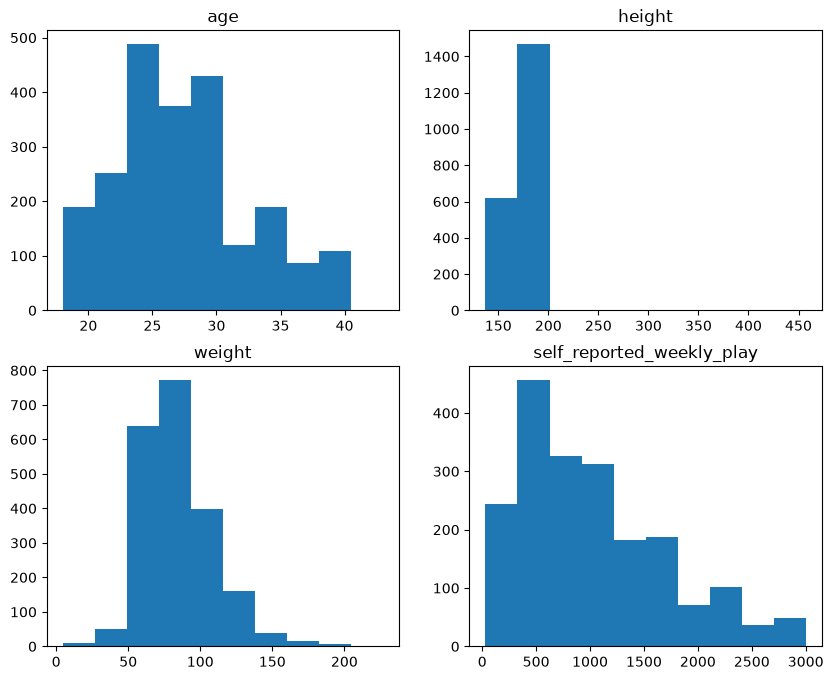

In [4]:
# demographic info histograms

qualified_participants = pd.DataFrame(survey_intake[survey_intake["qualified"] == True])
qp_cols_hist = ['age', 'height', 'weight', 'self_reported_weekly_play']


fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(qualified_participants[qualified_participants[qp_cols_hist[0]].notna()][qp_cols_hist[0]])
axes[0, 0].set_title(qp_cols_hist[0])

axes[0, 1].hist(qualified_participants[qualified_participants[qp_cols_hist[1]].notna()][qp_cols_hist[1]])
axes[0, 1].set_title(qp_cols_hist[1])

axes[1, 0].hist(qualified_participants[qualified_participants[qp_cols_hist[2]].notna()][qp_cols_hist[2]])
axes[1, 0].set_title(qp_cols_hist[2])

axes[1, 1].hist(qualified_participants[qualified_participants[qp_cols_hist[3]].notna()][qp_cols_hist[3]])
axes[1, 1].set_title(qp_cols_hist[3])

plt.show()

In [5]:
qp_cols = [
    'country','cohort', 'gender',  'ethnicity',
    'edu_level', 'marital_status', 'political_party', 'employment',
    'used_platforms','neuro_identify', 'neuro_diagnosed',
    'neuro_diag_asd', 'neuro_diag_adhd', 'neuro_diag_dyslexia',
    'neuro_diag_dyspraxia', 'neuro_diag_dyscalculia', 'neuro_diag_tourette',
    'neuro_diag_ocd', 'neuro_diag_spd', 'neuro_diag_nvld',
    'neuro_diag_specific_ld', 'neuro_diag_prefer_not_say',
    'neuro_diag_other', 'neuro_iden_asd', 'neuro_iden_adhd',
    'neuro_iden_dyslexia', 'neuro_iden_dyspraxia', 'neuro_iden_dyscalculia',
    'neuro_iden_tourette', 'neuro_iden_ocd', 'neuro_iden_spd',
    'neuro_iden_nvld', 'neuro_iden_specific_ld',
    'neuro_iden_prefer_not_say', 'neuro_iden_other', 'care_children',
    'care_elderly', 'care_disability', 'care_none', 'care_prefer_not_say',
    'care_other', 'dependents', 'life_sat']

for col in qp_cols:
    print(qualified_participants[col].value_counts(), "\n")

country
US    1305
UK     933
Name: count, dtype: int64 

cohort
Platform Prolific       2160
Platform Pilot            40
Platform Pureprofile      38
Name: count, dtype: int64 

gender
Man                    1486
Woman                   610
Non-binary              124
Prefer not to say         4
Agender                   2
Trans woman               1
gender-fluid              1
transmasc lesbian         1
Demi-boy                  1
Bigender Trans Male       1
He/They                   1
Genderfluid               1
trans woman               1
Questioning               1
genderqueer               1
Demiman                   1
agender                   1
Name: count, dtype: int64 

ethnicity
White alone                                         810
White                                               774
Two or More Races                                   184
Black or African American alone                     116
Asian alone                                         113
Asian or Asian Brit

In [6]:
user_info = survey_intake.set_index("pid").to_dict("index")

user_info

{'p7856647245': {'date': '2024-10-03T10:14:10Z',
  'qualified': False,
  'survey_duration': 136,
  'country': 'US',
  'geo_area': '037',
  'panel_source': nan,
  'cohort': 'Platform Pureprofile',
  'diaries_completed': 0,
  'panels_completed': 0,
  'local_timezone': nan,
  'age': 26,
  'gender': 'Man',
  'height': nan,
  'weight': nan,
  'ethnicity': nan,
  'edu_level': 'Other qualifications',
  'marital_status': 'Divorced',
  'political_party': 'Independent',
  'employment': 'Not currently employed',
  'self_reported_weekly_play': nan,
  'used_platforms': 'Steam,Nintendo Switch',
  'eligible_platforms': 'Steam, Nintendo',
  'linked_platforms': nan,
  'plays_xbox': False,
  'plays_steam': True,
  'plays_nintendo': True,
  'plays_ios': False,
  'plays_android': False,
  'plays_playstation': False,
  'prop_steam': 31.0,
  'prop_xbox': nan,
  'prop_playstation': nan,
  'prop_nintendo': 69.0,
  'prop_ios': nan,
  'prop_android': nan,
  'prop_other': nan,
  'nintendo_uses_family': 'No',
  '

In [7]:
xbox["platform"] = xbox.apply(lambda _: 'xbox', axis=1)
steam["platform"] = steam.apply(lambda _: 'steam', axis=1)
nintendo["platform"] = nintendo.apply(lambda _: 'nintendo', axis=1)

gaming_logs = pd.concat([xbox[["pid", "title_id", "session_start", "session_end", ".had_overlap", "duration", "platform"]], 
           steam[["pid", "title_id", "session_start", "session_end", "duration", "playtime_forever", "platform"]],
           nintendo[["pid",	"title_id",	"session_start",	"session_end",	"duration", "platform"]]
           ], ignore_index=True)

gaming_logs

,pid,title_id,session_start,session_end,.had_overlap,duration,platform,playtime_forever
0,p1049789162,9D2BEC81-A614-42F5-B00A-C350C2A215EE,2025-07-08 18:22:20+00:00,2025-07-08 18:29:26+00:00,False,7.100000,xbox,NaN
1,p1092839713,B5A4EA0E-2901-420F-8DAF-0D00CCBA5D2F,2022-05-01 00:00:00+00:00,2022-05-01 00:15:00+00:00,False,15.000000,xbox,NaN
2,p1092839713,B5A4EA0E-2901-420F-8DAF-0D00CCBA5D2F,2022-05-03 21:40:00+00:00,2022-05-03 22:50:00+00:00,False,70.000000,xbox,NaN
3,p1092839713,B5A4EA0E-2901-420F-8DAF-0D00CCBA5D2F,2022-05-06 20:15:00+00:00,2022-05-06 21:30:00+00:00,False,75.000000,xbox,NaN
4,p1092839713,B5A4EA0E-2901-420F-8DAF-0D00CCBA5D2F,2022-05-07 15:10:00+00:00,2022-05-07 16:00:00+00:00,False,50.000000,xbox,NaN
...,...,...,...,...,...,...,...,...
1734155,p9997778313,The Legend of Zelda Tears of the Kingdom,2023-05-28 10:31:03+00:00,2023-05-28 12:02:33+00:00,NaN,91.500000,nintendo,NaN
1734156,p9997778313,The Legend of Zelda Tears of the Kingdom,2023-05-28 15:41:42+00:00,2023-05-28 16:18:02+00:00,NaN,36.333333,nintendo,NaN
1734157,p9997778313,The Legend of Zelda Tears of the Kingdom,2023-05-28 17:43:44+00:00,2023-05-28 22:21:54+00:00,NaN,278.166667,nintendo,NaN
1734158,p9997778313,The Legend of Zelda Tears of the Kingdom,2023-05-29 17:42:20+00:00,2023-05-29 20:27:46+00:00,NaN,165.433333,nintendo,NaN


In [8]:
# Did Donald Trump's win affect gaming habits
## Find general playtime for US players
## Plot playtime between October 2024 to March 2025
## Color by Political affiliations

per_pid_per_day = gaming_logs.groupby([gaming_logs.pid, gaming_logs.session_start.dt.date], as_index=False).duration.sum()
per_pid_per_day.sort_values(by="duration", ascending=False)

per_pid_per_day["political_party"] = per_pid_per_day["pid"].apply(lambda pid: user_info[pid]["political_party"])
per_pid_per_day["country"] = per_pid_per_day["pid"].apply(lambda pid: user_info[pid]["country"])
per_pid_per_day['weeknumber'] = per_pid_per_day.session_start.apply(lambda date: f"{date.isocalendar().year}-{date.isocalendar().week:02}")
per_pid_per_day_us = per_pid_per_day[per_pid_per_day.country == "US"]

In [9]:
us_political_parties_clean = {
    "Right-leaning" : ["Republican Party", "libertarian","Libertarian Party", "Libertarian" ],
    "Left-leaning" : ["Democratic Party", "Either Democratic or Independent", "IDK any more...extremely liberal. Usually vote for democrats", 
                    "Leftist", "leftist", "Democratic Socialist", "Against corporate oligarchy, Left Leaning, FOR the Working Class", 
                   "Socialist", "Leftist/Green/Progressive", "Communist", "Green", "Left Leaning (not liberal/democratic)", "Left leaning centrist", "socialist",
                   "Anarcho communist", "Leftist, no party affiliation", "socialist voting dem", "Socialist party", "Green or Socialist", 
                   "Peace and Freedom/Socialist", "Registered as independent but vote Democrat"],
    "Independent" : ["Independent"],
    "Centrist" : ["moderate", "Center"],
    "Apolitical" : ["Prefer not to say", "no political affiliation", "none", "Non-Political", "I dont pay enough attention to politics to know",
                    "Unaffiliated", "non political", "No political affiliation", np.nan, "No political party affiliation", "Apolitical", "Unaffiliated"]
}

us_political_parties_clean = {value : key for  key, values in us_political_parties_clean.items() for value in values}

per_pid_per_day_us["political_party_divisions"] = per_pid_per_day_us.political_party.apply(lambda po: us_political_parties_clean[po])
per_pid_per_day_us

,pid,session_start,duration,political_party,country,weeknumber,political_party_divisions
0,p1003299452,2025-03-01,344.516667,Independent,US,2025-09,Independent
1,p1003299452,2025-04-17,31.000000,Independent,US,2025-16,Independent
2,p1003299452,2025-04-23,401.983333,Independent,US,2025-17,Independent
3,p1003299452,2025-04-24,265.083333,Independent,US,2025-17,Independent
4,p1003299452,2025-04-25,161.000000,Independent,US,2025-17,Independent
...,...,...,...,...,...,...,...
465376,p9996920974,2025-10-02,378.558680,Democratic Party,US,2025-40,Left-leaning
465377,p9996920974,2025-10-03,360.983333,Democratic Party,US,2025-40,Left-leaning
465378,p9996920974,2025-10-04,310.183333,Democratic Party,US,2025-40,Left-leaning
465379,p9996920974,2025-10-05,333.716667,Democratic Party,US,2025-40,Left-leaning


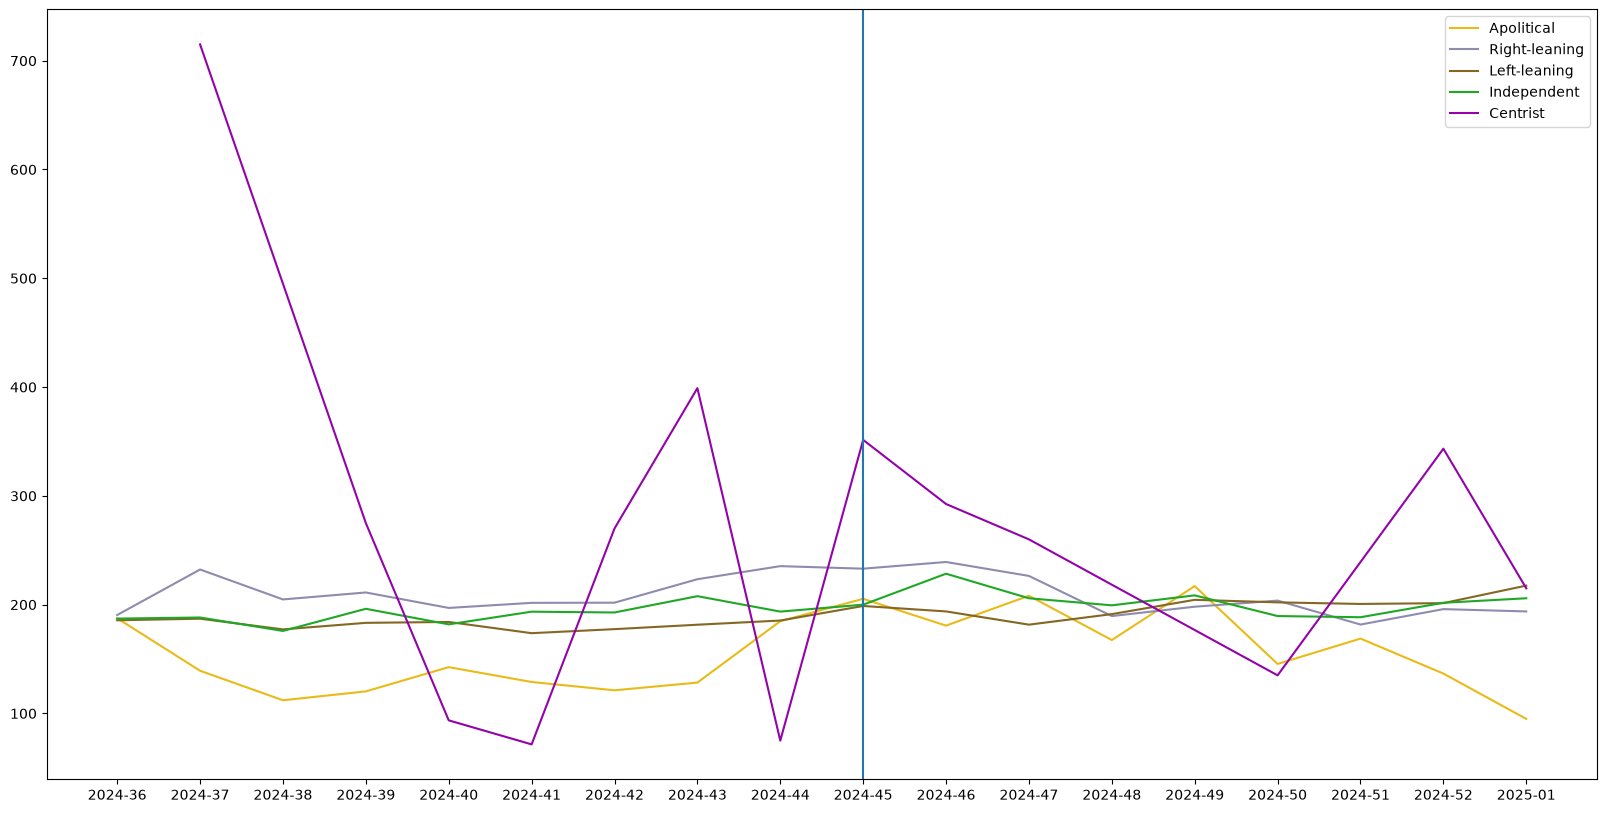

In [10]:
plt.figure(figsize=(20, 10))

trump_effect = per_pid_per_day_us[(per_pid_per_day_us.session_start > date(2024, 9, 5)) & (per_pid_per_day_us.session_start < date(2025, 1, 5))]

def random_hex():
    return f"#{random.randint(0,255):02X}{random.randint(0,255):02X}{random.randint(0,255):02X}"

for po in trump_effect.political_party_divisions.unique():
    filter_df = trump_effect[trump_effect["political_party_divisions"] == po].groupby(["weeknumber"], as_index=False).duration.mean()
    plt.plot(filter_df.weeknumber, filter_df.duration, color=random_hex(), label=po)

plt.axvline("2024-45")
plt.legend()  
plt.show()


Above graph does not show any obvious patterns hence we wont consider it for further analysis.

#### When a new game is released, do people play for longer? Does this increase their happiness?

gamemetadata - release date  
playtime graphed with release date line  
overlay with wellbeing composite index  

In [11]:
survey_biweekly["wellbeing_index"] = (((survey_biweekly.life_sat * 4)/10) + 
    40 - (survey_biweekly.promis_1 + survey_biweekly.promis_2 + survey_biweekly.promis_3 + survey_biweekly.promis_4 + 
    survey_biweekly.promis_5 + survey_biweekly.promis_6 + survey_biweekly.promis_7 + survey_biweekly.promis_8) + 
    survey_biweekly.wemwbs_1 + survey_biweekly.wemwbs_2 + survey_biweekly.wemwbs_3 + survey_biweekly.wemwbs_4 +  
    survey_biweekly.wemwbs_5 + survey_biweekly.wemwbs_6 + survey_biweekly.wemwbs_7 - 7)/16 * 10/4

survey_biweekly

,pid,wave,date,survey_duration,affective_valence,life_sat,self_reported_daily_play,self_reported_weekly_play,self_reported_biweekly_play,bangs_1,...,trojan_15,wemwbs_1,wemwbs_2,wemwbs_3,wemwbs_4,wemwbs_5,wemwbs_6,wemwbs_7,played_any_games,wellbeing_index
0,p100362329,1,2024-10-02 14:32:19+00:00,526,65.0,3.0,270.0,1800.0,3600.0,6.0,...,4.0,2.0,3.0,4.0,5.0,4.0,2.0,3.0,NaN,6.43750
1,p1009647790,1,2025-03-27 21:21:33+00:00,688,52.0,2.0,240.0,1200.0,2400.0,4.0,...,2.0,3.0,2.0,3.0,3.0,2.0,2.0,3.0,Yes,3.40625
2,p1009647790,2,2025-04-10 21:15:34+00:00,515,69.0,2.0,240.0,1500.0,3000.0,6.0,...,NaN,3.0,3.0,3.0,2.0,2.0,2.0,3.0,Yes,4.34375
3,p1009647790,3,2025-04-24 21:26:57+00:00,443,72.0,2.0,240.0,1800.0,4380.0,4.0,...,NaN,3.0,3.0,4.0,4.0,3.0,3.0,4.0,Yes,5.28125
4,p1009647790,4,2025-05-08 21:55:59+00:00,468,74.0,2.0,300.0,1500.0,3000.0,6.0,...,NaN,2.0,3.0,3.0,2.0,2.0,1.0,2.0,Yes,4.34375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6839,p9998167087,2,2025-06-19 22:49:26+00:00,267,85.0,7.0,60.0,360.0,780.0,7.0,...,NaN,3.0,4.0,4.0,3.0,4.0,3.0,4.0,Yes,7.62500
6840,p9998167087,3,2025-07-03 20:45:41+00:00,196,82.0,8.0,30.0,180.0,600.0,5.0,...,NaN,4.0,4.0,4.0,4.0,4.0,3.0,3.0,Yes,7.84375
6841,p9998167087,4,2025-07-18 02:17:06+00:00,249,81.0,6.0,0.0,180.0,420.0,6.0,...,NaN,3.0,3.0,4.0,3.0,4.0,4.0,4.0,Yes,7.40625
6842,p9998167087,5,2025-08-01 20:00:54+00:00,160,69.0,7.0,30.0,180.0,300.0,6.0,...,NaN,4.0,3.0,3.0,4.0,4.0,3.0,3.0,Yes,6.84375


In [12]:

def playtime_2weeks(row):
    if row.name % 50 == 0:
        print(row.name)

    return gaming_logs[(gaming_logs.pid == row.pid) & (row.date - timedelta(days=14) < gaming_logs.session_start) & (gaming_logs.session_start < row.date)].duration.sum()/14

survey_biweekly["playtime_2weeks"] = survey_biweekly.apply(playtime_2weeks, axis=1)
survey_biweekly


0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
2050
2100
2150
2200
2250
2300
2350
2400
2450
2500
2550
2600
2650
2700
2750
2800
2850
2900
2950
3000
3050
3100
3150
3200
3250
3300
3350
3400
3450
3500
3550
3600
3650
3700
3750
3800
3850
3900
3950
4000
4050
4100
4150
4200
4250
4300
4350
4400
4450
4500
4550
4600
4650
4700
4750
4800
4850
4900
4950
5000
5050
5100
5150
5200
5250
5300
5350
5400
5450
5500
5550
5600
5650
5700
5750
5800
5850
5900
5950
6000
6050
6100
6150
6200
6250
6300
6350
6400
6450
6500
6550
6600
6650
6700
6750
6800


,pid,wave,date,survey_duration,affective_valence,life_sat,self_reported_daily_play,self_reported_weekly_play,self_reported_biweekly_play,bangs_1,...,wemwbs_1,wemwbs_2,wemwbs_3,wemwbs_4,wemwbs_5,wemwbs_6,wemwbs_7,played_any_games,wellbeing_index,playtime_2weeks
0,p100362329,1,2024-10-02 14:32:19+00:00,526,65.0,3.0,270.0,1800.0,3600.0,6.0,...,2.0,3.0,4.0,5.0,4.0,2.0,3.0,NaN,6.43750,0.000000
1,p1009647790,1,2025-03-27 21:21:33+00:00,688,52.0,2.0,240.0,1200.0,2400.0,4.0,...,3.0,2.0,3.0,3.0,2.0,2.0,3.0,Yes,3.40625,171.944048
2,p1009647790,2,2025-04-10 21:15:34+00:00,515,69.0,2.0,240.0,1500.0,3000.0,6.0,...,3.0,3.0,3.0,2.0,2.0,2.0,3.0,Yes,4.34375,162.420238
3,p1009647790,3,2025-04-24 21:26:57+00:00,443,72.0,2.0,240.0,1800.0,4380.0,4.0,...,3.0,3.0,4.0,4.0,3.0,3.0,4.0,Yes,5.28125,292.680952
4,p1009647790,4,2025-05-08 21:55:59+00:00,468,74.0,2.0,300.0,1500.0,3000.0,6.0,...,2.0,3.0,3.0,2.0,2.0,1.0,2.0,Yes,4.34375,192.841667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6839,p9998167087,2,2025-06-19 22:49:26+00:00,267,85.0,7.0,60.0,360.0,780.0,7.0,...,3.0,4.0,4.0,3.0,4.0,3.0,4.0,Yes,7.62500,0.000000
6840,p9998167087,3,2025-07-03 20:45:41+00:00,196,82.0,8.0,30.0,180.0,600.0,5.0,...,4.0,4.0,4.0,4.0,4.0,3.0,3.0,Yes,7.84375,0.000000
6841,p9998167087,4,2025-07-18 02:17:06+00:00,249,81.0,6.0,0.0,180.0,420.0,6.0,...,3.0,3.0,4.0,3.0,4.0,4.0,4.0,Yes,7.40625,0.000000
6842,p9998167087,5,2025-08-01 20:00:54+00:00,160,69.0,7.0,30.0,180.0,300.0,6.0,...,4.0,3.0,3.0,4.0,4.0,3.0,3.0,Yes,6.84375,0.000000


In [13]:
total_playtime_ever_per_pid = gaming_logs.groupby(by="pid").duration.sum().to_dict()

survey_biweekly["total_playtime_ever"] = survey_biweekly.pid.apply(lambda pid: total_playtime_ever_per_pid.get(pid, 0))
survey_biweekly

,pid,wave,date,survey_duration,affective_valence,life_sat,self_reported_daily_play,self_reported_weekly_play,self_reported_biweekly_play,bangs_1,...,wemwbs_2,wemwbs_3,wemwbs_4,wemwbs_5,wemwbs_6,wemwbs_7,played_any_games,wellbeing_index,playtime_2weeks,total_playtime_ever
0,p100362329,1,2024-10-02 14:32:19+00:00,526,65.0,3.0,270.0,1800.0,3600.0,6.0,...,3.0,4.0,5.0,4.0,2.0,3.0,NaN,6.43750,0.000000,0.00
1,p1009647790,1,2025-03-27 21:21:33+00:00,688,52.0,2.0,240.0,1200.0,2400.0,4.0,...,2.0,3.0,3.0,2.0,2.0,3.0,Yes,3.40625,171.944048,38407.35
2,p1009647790,2,2025-04-10 21:15:34+00:00,515,69.0,2.0,240.0,1500.0,3000.0,6.0,...,3.0,3.0,2.0,2.0,2.0,3.0,Yes,4.34375,162.420238,38407.35
3,p1009647790,3,2025-04-24 21:26:57+00:00,443,72.0,2.0,240.0,1800.0,4380.0,4.0,...,3.0,4.0,4.0,3.0,3.0,4.0,Yes,5.28125,292.680952,38407.35
4,p1009647790,4,2025-05-08 21:55:59+00:00,468,74.0,2.0,300.0,1500.0,3000.0,6.0,...,3.0,3.0,2.0,2.0,1.0,2.0,Yes,4.34375,192.841667,38407.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6839,p9998167087,2,2025-06-19 22:49:26+00:00,267,85.0,7.0,60.0,360.0,780.0,7.0,...,4.0,4.0,3.0,4.0,3.0,4.0,Yes,7.62500,0.000000,0.00
6840,p9998167087,3,2025-07-03 20:45:41+00:00,196,82.0,8.0,30.0,180.0,600.0,5.0,...,4.0,4.0,4.0,4.0,3.0,3.0,Yes,7.84375,0.000000,0.00
6841,p9998167087,4,2025-07-18 02:17:06+00:00,249,81.0,6.0,0.0,180.0,420.0,6.0,...,3.0,4.0,3.0,4.0,4.0,4.0,Yes,7.40625,0.000000,0.00
6842,p9998167087,5,2025-08-01 20:00:54+00:00,160,69.0,7.0,30.0,180.0,300.0,6.0,...,3.0,3.0,4.0,4.0,3.0,3.0,Yes,6.84375,0.000000,0.00


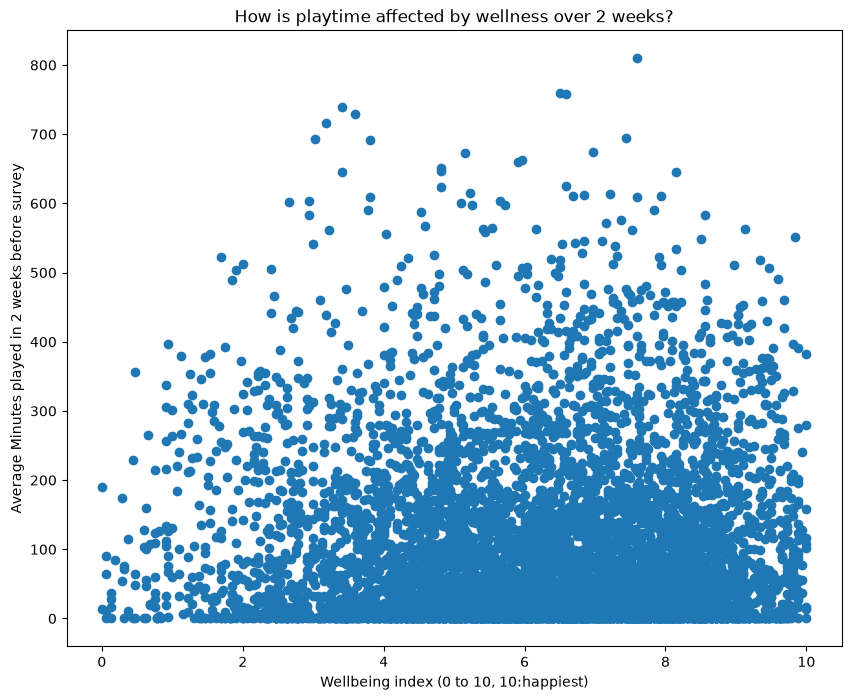

In [14]:
# Wellness v/s playtime graph

users_with_data = survey_biweekly[survey_biweekly.total_playtime_ever > 0]

plt.figure(figsize=(10, 8))
plt.scatter(users_with_data.wellbeing_index, users_with_data.playtime_2weeks)
plt.xlabel("Wellbeing index (0 to 10, 10:happiest)")
plt.ylabel("Average Minutes played in 2 weeks before survey")
plt.title("How is playtime affected by wellness over 2 weeks?")
plt.show()

(array([  48.,    0.,    0.,   64.,  528., 1127., 1090., 1911., 1383.,
         693.]),
 array([19997.79284722, 20033.88593403, 20069.97902083, 20106.07210764,
        20142.16519444, 20178.25828125, 20214.35136806, 20250.44445486,
        20286.53754167, 20322.63062847, 20358.72371528]),
 <BarContainer object of 10 artists>)

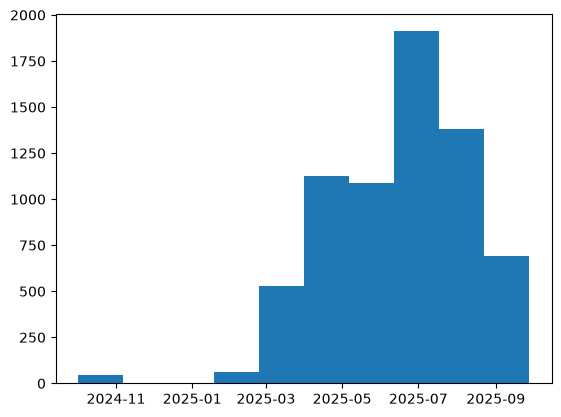

In [15]:
# games released between which dates should we consider? Survey biweekly ie wellbeing index will only be available for certain dates.

plt.hist(survey_biweekly.date)

(array([  3010.,   8225.,  28807.,  73757.,  68113.,  73970., 149129.,
        150190., 139950., 142030.]),
 array([20057., 20088., 20119., 20150., 20181., 20212., 20243., 20274.,
        20305., 20336., 20367.]),
 <BarContainer object of 10 artists>)

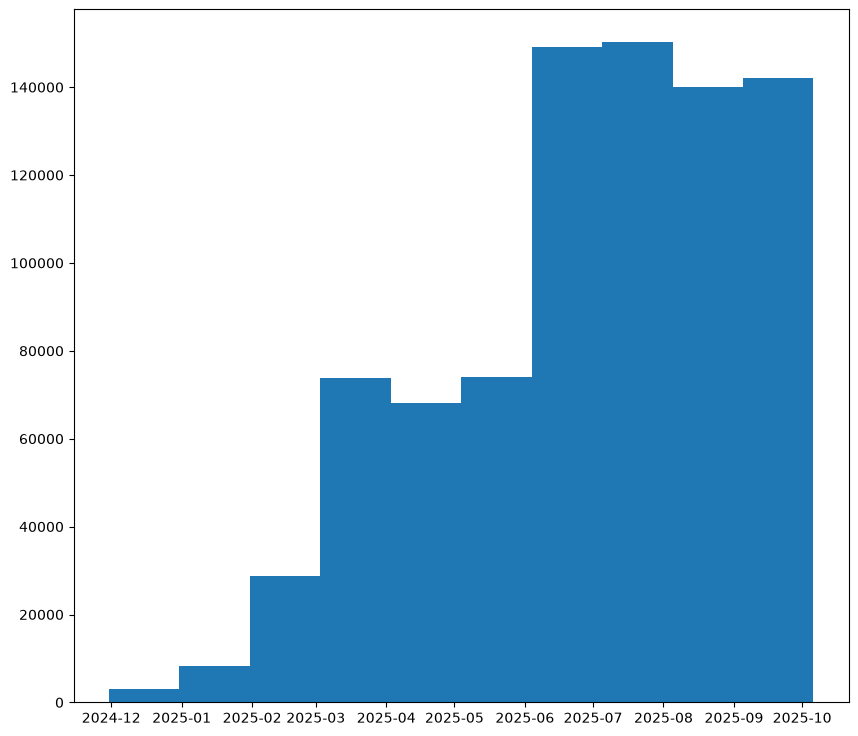

In [158]:
# spike in steam
plt.figure(figsize=(10, 9))
plt.hist(gaming_logs[(gaming_logs.session_start.dt.date < date(2025, 12, 1)) & (gaming_logs.session_end.dt.date > date(2024, 1, 1))  & (gaming_logs.platform == "steam")].session_start.dt.date)

(array([117., 103., 131.,  92., 149., 133.,  92., 180., 143., 131.]),
 array([20149. , 20167.2, 20185.4, 20203.6, 20221.8, 20240. , 20258.2,
        20276.4, 20294.6, 20312.8, 20331. ]),
 <BarContainer object of 10 artists>)

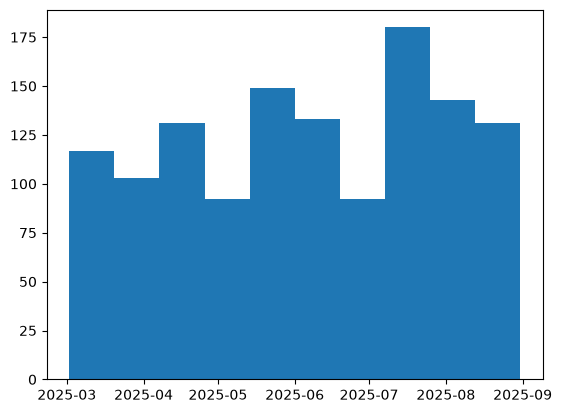

In [ ]:
# Do the spikes exist in nintendo
plt.hist(game_metadata[(game_metadata.release_date.dt.date.notna()) & (game_metadata.release_date.dt.date > date(2025, 3, 1)) & (game_metadata.release_date.dt.date < date(2025, 9, 1))].release_date.dt.date)

In [ ]:
# spike observed in june 2025 1st week in steam. Which games are the highest played during this period and when were they released?

spike = gaming_logs[(gaming_logs.session_start.dt.date < date(2025, 6, 10)) & (gaming_logs.session_end.dt.date > date(2025, 6, 1))  & (gaming_logs.platform == "steam")].groupby(by = "title_id").duration.sum().sort_values(ascending=False)
game_info = game_metadata[(game_metadata.platform == "Steam")][["original_name", "release_date"]].set_index("original_name")

pd.concat([spike, game_info], axis=1)

,duration,release_date
ELDEN RING NIGHTREIGN,80796.802315,2025-05-30 00:00:00+00:00
Marvel Rivals,55539.448369,2024-12-06 00:00:00+00:00
DELTARUNE,39046.846819,2025-06-04 00:00:00+00:00
Counter-Strike 2,34992.148590,2023-09-27 00:00:00+00:00
Baldur's Gate 3,33079.251565,2023-08-03 00:00:00+00:00
...,...,...
천년의 소녀 Demo,NaN,NaT
총알배달 우주반점,NaN,NaT
하숙생이 전부 미녀입니다만? Demo,NaN,2025-10-19 00:00:00+00:00
８番出口,NaN,NaT


In [ ]:
# spike observed in march 2025 1st week. Which games are the highest played during this period and when were they released?

spike2 = gaming_logs[(gaming_logs.session_start.dt.date < date(2025, 4, 10)) & (gaming_logs.session_end.dt.date > date(2025, 2, 10))  & (gaming_logs.platform == "steam")].groupby(by = "title_id").duration.sum().sort_values(ascending=False)
game_info2 = game_metadata[(game_metadata.platform == "Steam")][["original_name", "release_date"]].set_index("original_name")

pd.concat([spike2, game_info2], axis=1)

,duration,release_date
Marvel Rivals,257643.349715,2024-12-06 00:00:00+00:00
Monster Hunter Wilds,173969.744457,2025-02-28 00:00:00+00:00
R.E.P.O.,138747.200496,2025-02-26 00:00:00+00:00
Counter-Strike 2,119196.735930,2023-09-27 00:00:00+00:00
Overwatch® 2,104798.868679,2023-08-10 00:00:00+00:00
...,...,...
위험한 그놈들-여성향 스릴러 연애 스토리,NaN,NaT
천년의 소녀 Demo,NaN,NaT
총알배달 우주반점,NaN,NaT
하숙생이 전부 미녀입니다만? Demo,NaN,2025-10-19 00:00:00+00:00


gaming logs: duration v/s session starts from jan 2025 to dec 2025  
vertical lines for game release dates with playtimes higher than 5h right after release  
line graph of wellbeing_index

In [161]:
# grouped playtime for all players who answered in survey

per_day_2025 = gaming_logs[(gaming_logs.session_start.dt.date > date(2024, 1, 1)) & (gaming_logs.session_start.dt.date < date(2025, 9, 30))]

log_and_survey = {}
for pid in per_day_2025.pid.unique():
    log_and_survey[pid] = True if pid in users_with_data.pid.to_list() else False

per_day_2025["survey"] = per_day_2025.pid.apply(lambda pid: log_and_survey[pid])
per_day_2025 = per_day_2025[per_day_2025.survey == True]

per_month_2025 = per_day_2025.groupby([per_day_2025.session_start.dt.year, per_day_2025.session_start.dt.month], as_index=False).duration.mean()
per_day_2025 = per_day_2025.groupby(per_day_2025.session_start.dt.date, as_index=False).duration.sum()
per_day_2025.rename(columns={"duration" : "avg_duration",
                             "session_start" : "date"}, inplace=True)
per_day_2025

,date,avg_duration
0,2024-01-02,27747.383333
1,2024-01-03,24892.550000
2,2024-01-04,26464.966667
3,2024-01-05,26601.416667
4,2024-01-06,29354.916667
...,...,...
632,2025-09-25,140717.746453
633,2025-09-26,149573.330840
634,2025-09-27,154973.781530
635,2025-09-28,164288.076396


In [ ]:
biweekly_wellbeing = users_with_data[["pid", "date", "wellbeing_index"]].reset_index(drop=True)
biweekly_wellbeing.date = biweekly_wellbeing.date.dt.date
biweekly_wellbeing = biweekly_wellbeing.groupby("date", as_index=False).wellbeing_index.mean()
biweekly_wellbeing = biweekly_wellbeing[biweekly_wellbeing.wellbeing_index.notna() == True]

biweekly_wellbeing

,date,wellbeing_index,wellbeing_index_smooth
0,2025-02-12,6.739583,6.402755
1,2025-02-13,5.756579,6.399027
2,2025-02-14,2.140625,6.395318
3,2025-02-15,5.609375,6.391628
4,2025-02-16,4.875000,6.387956
...,...,...,...
208,2025-09-20,6.665625,6.260551
209,2025-09-21,6.706250,6.255329
210,2025-09-22,6.709375,6.249933
211,2025-09-23,6.343750,6.244362


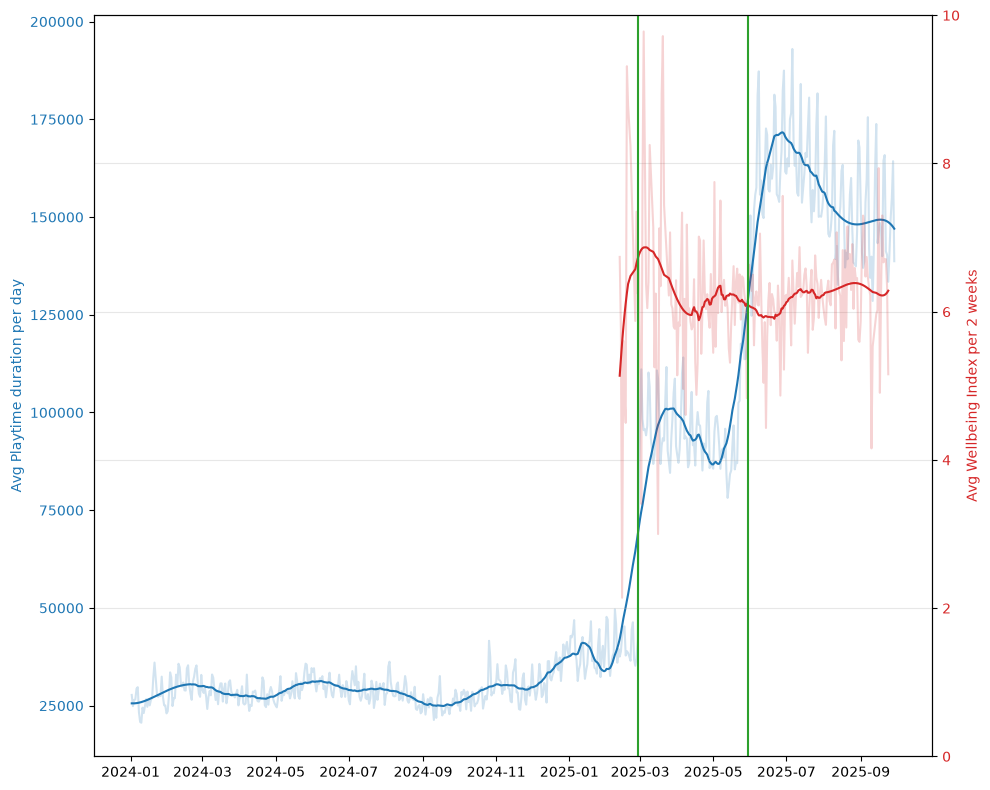

In [163]:
per_day_2025["avg_duration_smooth"] = savgol_filter(per_day_2025.avg_duration, 100, 4)
biweekly_wellbeing["wellbeing_index_smooth"] = savgol_filter(biweekly_wellbeing.wellbeing_index, 100, 6)

fig, ax1 = plt.subplots(figsize=(10,8))


color = "tab:blue"
ax1.set_ylabel("Avg Playtime duration per day", color=color)
ax1.plot(per_day_2025.date, per_day_2025.avg_duration_smooth, c=color)
ax1.tick_params(axis="y", labelcolor=color)

ax1.plot(per_day_2025.date, per_day_2025.avg_duration, c=color, alpha=0.2)

ax2 = ax1.twinx() 
color = "tab:red"
ax2.set_ylabel("Avg Wellbeing Index per 2 weeks", color=color)  
ax2.plot(biweekly_wellbeing.date, biweekly_wellbeing.wellbeing_index_smooth, color=color)
ax2.tick_params(axis="y", labelcolor=color)
ax2.set_ylim(0, 10)

ax2.plot(biweekly_wellbeing.date, biweekly_wellbeing.wellbeing_index, color=color, alpha=0.2)

plt.axvline(date(2025, 5, 30), c="tab:green")
plt.axvline(date(2025, 2, 27), c="tab:green")

fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()

# smooth graph
# minutes on y change to hours